# AMS Prediction Model — 5 Feature Retrain
**Real-Time Prediction System for Acute Mountain Sickness in Nepal's Himalayas**

This notebook retrains the AMS prediction model using only the **5 features that the ESP32 hardware can actually measure**:

| Feature | Sensor |
|---|---|
| `spo2_pct` | MAX30102 |
| `heart_rate` | MAX30102 |
| `altitude` | BMP180 |
| `ascent_rate` | Calculated from altitude over time |
| `hours_at_altitude` | Tracked by ESP32 timer |



## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load Dataset

In [2]:
df = pd.read_csv('ams_training_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nAMS Risk Distribution:')

risk_labels = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Severe'}
for i in range(4):
    count = (df['ams_risk'] == i).sum()
    print(f'  {risk_labels[i]:8s} ({i}): {count:,} ({count/len(df)*100:.1f}%)')

df.head()

Dataset shape: (300000, 11)

Columns: ['spo2_pct', 'heart_rate', 'respiratory_rate', 'temperature_c', 'age', 'gender', 'gender_numeric', 'hours_at_altitude', 'altitude', 'ascent_rate', 'ams_risk']

AMS Risk Distribution:
  Low      (0): 142,906 (47.6%)
  Medium   (1): 87,501 (29.2%)
  High     (2): 43,403 (14.5%)
  Severe   (3): 26,190 (8.7%)


,spo2_pct,heart_rate,respiratory_rate,temperature_c,age,gender,gender_numeric,hours_at_altitude,altitude,ascent_rate,ams_risk
0,91.1,66.64,26.92,36.06,52,M,1,46,3484,45,0
1,97.0,60.54,24.80,36.34,74,M,1,42,2353,48,0
2,93.2,84.63,19.99,36.78,58,F,0,23,2056,67,0
3,87.7,76.41,18.44,37.28,51,F,0,2,3032,56,1
4,84.1,81.00,26.90,36.39,35,M,1,9,4626,55,3


## 3. Select Features (ESP32 Measurable Only)

In [3]:
FEATURE_COLUMNS = [
    'spo2_pct',
    'heart_rate',
    'altitude',
    'ascent_rate',
    'hours_at_altitude'
]

DROPPED_FEATURES = ['respiratory_rate', 'temperature_c', 'age', 'gender_numeric']

X = df[FEATURE_COLUMNS].copy()
y = df['ams_risk'].copy()

print('Features used for training:')
for f in FEATURE_COLUMNS:
    print(f'  + {f}')

print('\nDropped (not measurable by ESP32):')
for f in DROPPED_FEATURES:
    print(f'  - {f}')

print(f'\nFeature matrix shape: {X.shape}')
X.describe()

Features used for training:
  + spo2_pct
  + heart_rate
  + altitude
  + ascent_rate
  + hours_at_altitude

Dropped (not measurable by ESP32):
  - respiratory_rate
  - temperature_c
  - age
  - gender_numeric

Feature matrix shape: (300000, 5)


,spo2_pct,heart_rate,altitude,ascent_rate,hours_at_altitude
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,89.629945,89.307404,3292.498647,54.881820,24.108397
std,6.183739,21.115817,960.583455,26.486118,16.939370
min,70.000000,40.000000,1400.000000,0.000000,0.000000
25%,87.200000,76.960000,2628.000000,37.000000,10.000000
50%,90.800000,86.380000,3252.000000,52.000000,21.000000
75%,93.700000,96.950000,4006.000000,70.000000,36.000000
max,100.000000,180.000000,5499.000000,143.000000,71.000000


## 4. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train):,}')
print(f'Testing samples  : {len(X_test):,}')
print(f'Split ratio      : 80/20')

Training samples : 240,000
Testing samples  : 60,000
Split ratio      : 80/20


## 5. Scale Features

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied')
print('Fit on training data only — transform applied to both train and test')

StandardScaler applied
Fit on training data only — transform applied to both train and test


## 6. Train Decision Tree Model

A **Decision Tree** is the right choice here because:
- The classification boundaries are essentially threshold rules (SpO2 < 90% → High risk)
- It learns the same logic a doctor would write by hand
- The tree can be printed and inspected — you can see exactly why it made a decision
- Much faster to train and predict than Random Forest on small medical datasets

`max_depth=4` keeps the tree readable while capturing all the important splits.

In [6]:
model = DecisionTreeClassifier(
    max_depth=4,       # Deep enough to learn all 4 risk levels; shallow enough to read
    random_state=42
)

print('Training Decision Tree...')
model.fit(X_train_scaled, y_train)
print('Training complete')
print(f'Tree depth used: {model.get_depth()}  (max allowed: 4)')
print(f'Leaf nodes     : {model.get_n_leaves()}')

# Print the human-readable decision tree
print('\n── Decision Tree Rules ──────────────────────────────────────')
tree_text = export_text(model, feature_names=FEATURE_COLUMNS)
print(tree_text)

Training Decision Tree...
Training complete
Tree depth used: 4  (max allowed: 4)
Leaf nodes     : 16

── Decision Tree Rules ──────────────────────────────────────
|--- spo2_pct <= 0.05
|   |--- spo2_pct <= -2.34
|   |   |--- heart_rate <= 1.42
|   |   |   |--- ascent_rate <= -0.17
|   |   |   |   |--- class: 2
|   |   |   |--- ascent_rate >  -0.17
|   |   |   |   |--- class: 3
|   |   |--- heart_rate >  1.42
|   |   |   |--- spo2_pct <= -2.37
|   |   |   |   |--- class: 3
|   |   |   |--- spo2_pct >  -2.37
|   |   |   |   |--- class: 3
|   |--- spo2_pct >  -2.34
|   |   |--- spo2_pct <= -0.76
|   |   |   |--- ascent_rate <= 0.78
|   |   |   |   |--- class: 2
|   |   |   |--- ascent_rate >  0.78
|   |   |   |   |--- class: 3
|   |   |--- spo2_pct >  -0.76
|   |   |   |--- ascent_rate <= 0.78
|   |   |   |   |--- class: 1
|   |   |   |--- ascent_rate >  0.78
|   |   |   |   |--- class: 2
|--- spo2_pct >  0.05
|   |--- ascent_rate <= 0.78
|   |   |--- altitude <= 0.74
|   |   |   |--- he

## 7. Evaluate Model

In [7]:
y_pred = model.predict(X_test_scaled)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print('=' * 50)
print('MODEL PERFORMANCE')
print('=' * 50)
print(f'Accuracy  : {accuracy*100:.2f}%')
print(f'Precision : {precision*100:.2f}%')
print(f'Recall    : {recall*100:.2f}%')
print(f'F1 Score  : {f1*100:.2f}%')
print()
print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Low', 'Medium', 'High', 'Severe']
))

MODEL PERFORMANCE
Accuracy  : 79.46%
Precision : 79.81%
Recall    : 79.46%
F1 Score  : 79.52%

Classification Report:
              precision    recall  f1-score   support

         Low       0.90      0.91      0.91     28581
      Medium       0.70      0.72      0.71     17500
        High       0.60      0.62      0.61      8681
      Severe       0.91      0.71      0.79      5238

    accuracy                           0.79     60000
   macro avg       0.78      0.74      0.75     60000
weighted avg       0.80      0.79      0.80     60000



## 9. Confusion Matrix

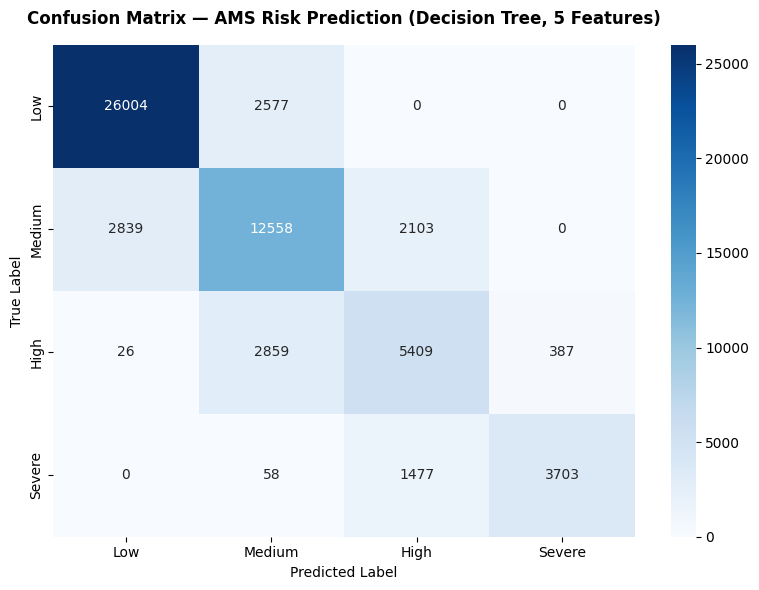

Saved: confusion_matrix.png


In [8]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Low', 'Medium', 'High', 'Severe']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — AMS Risk Prediction (Decision Tree, 5 Features)', fontweight='bold', pad=15)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

## 10. Feature Importance + Tree Visualisation

Feature Importance Ranking:
  spo2_pct               62.2%
  ascent_rate            27.6%
  altitude               8.3%
  heart_rate             2.0%
  hours_at_altitude      0.0%


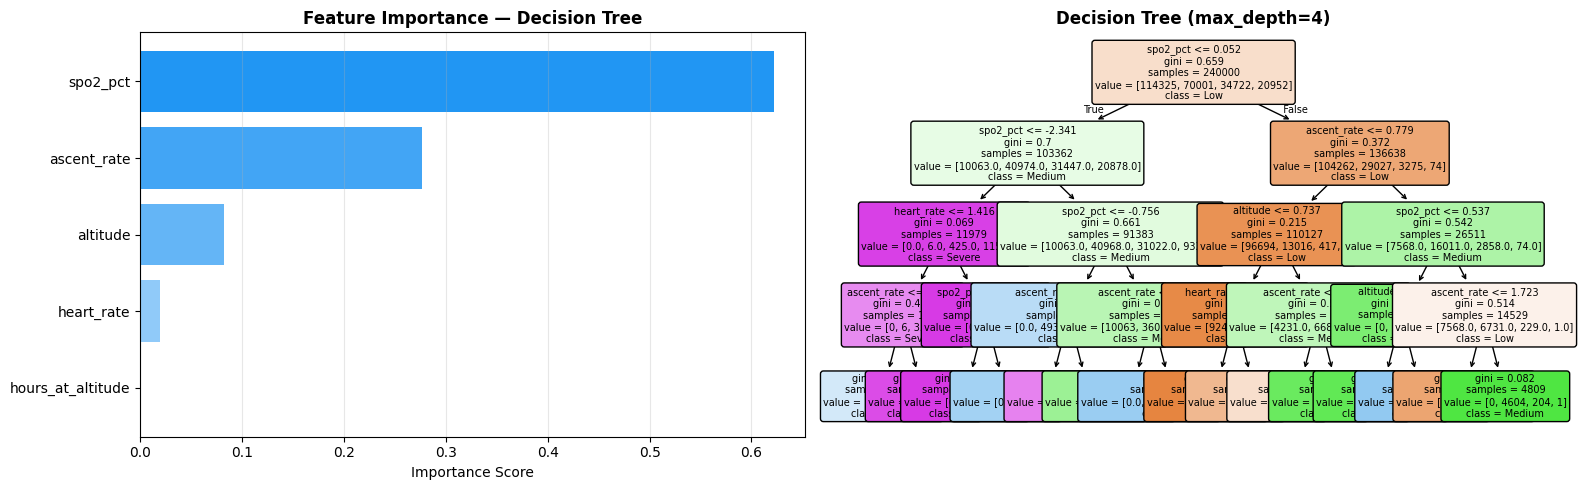

Saved: feature_importance.png


In [9]:
fi = pd.DataFrame({
    'Feature': FEATURE_COLUMNS,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Feature Importance Ranking:')
for _, row in fi.iterrows():
    print(f"  {row['Feature']:22s} {row['Importance']*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: bar chart ──
colors = ['#2196F3', '#42A5F5', '#64B5F6', '#90CAF9', '#BBDEFB']
axes[0].barh(fi['Feature'], fi['Importance'], color=colors)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Feature Importance — Decision Tree', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# ── Right: tree diagram ──
plot_tree(
    model,
    feature_names=FEATURE_COLUMNS,
    class_names=['Low', 'Medium', 'High', 'Severe'],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=axes[1]
)
axes[1].set_title('Decision Tree (max_depth=4)', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved: feature_importance.png')

## 11. Save Model Files

In [10]:
joblib.dump(model, 'ams_model.pkl')
print('Saved: ams_model.pkl')

joblib.dump(scaler, 'scaler.pkl')
print('Saved: scaler.pkl')

metadata = {
    'model_name'      : 'Decision Tree',
    'accuracy'        : accuracy,
    'precision'       : precision,
    'recall'          : recall,
    'f1_score'        : f1,
    'feature_columns' : FEATURE_COLUMNS,
    'risk_labels'     : ['Low', 'Medium', 'High', 'Severe'],
    'training_samples': len(X_train),
    'test_samples'    : len(X_test),
    'tree_depth'      : model.get_depth(),
    'leaf_nodes'      : model.get_n_leaves()
}
joblib.dump(metadata, 'model_metadata.pkl')
print('Saved: model_metadata.pkl')

print(f'\nModel       : Decision Tree (max_depth=4)')
print(f'Accuracy    : {accuracy*100:.2f}%')
print(f'Tree depth  : {model.get_depth()}')
print(f'Leaf nodes  : {model.get_n_leaves()}')
print('All model files saved — restart Flask to load the new model')

Saved: ams_model.pkl
Saved: scaler.pkl
Saved: model_metadata.pkl

Model       : Decision Tree (max_depth=4)
Accuracy    : 79.46%
Tree depth  : 4
Leaf nodes  : 16
All model files saved — restart Flask to load the new model
